<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Time Series EDA Lab

---

This lab covers the exploratory toolkit you need **before** fitting any time series model. It walks through: 

- Loading and indexing a real-world time series
- Visualizing trend by resampling / rolling smoothing
- Testing for stationarity with the Augmented Dickey-Fuller (ADF) test
- Diagnosing the series using ACF and PACF plots

## About the Data

`residents.csv` contains a **quarterly resident population count**, in thousands, from **April 1971 to April 1993** (89 quarters):

| Column | Description |
|---|---|
| `date` | Quarter (month-year, e.g. `04-1971`) |
| `residents` | Resident population that quarter, in thousands |

We're going to hold the **final 8 quarters (1991–1993)** out completely. Everything in this EDA lab uses only the first **81 quarters (1971–1990)**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use('fivethirtyeight')

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

## Part 1 - Load and Set Aside the Holdout 

### 1. Load `residents.csv`, parse `date` as a datetime (format is `MM-YYYY`), and set it as the index.

In [2]:
# YOUR CODE HERE
df = pd.read_csv('./data/residents.csv', parse_dates=['date'], date_format='%m-%Y')

In [3]:
df.set_index('date', inplace=True)
df.index.name = None

In [4]:
df.head()

,residents
1971-04-01,13067.3
1971-07-01,13130.5
1971-10-01,13198.4
1972-01-01,13254.2
1972-04-01,13303.7


### 2. Set aside the final 8 quarters (1991–1993) as `holdout_df`. Keep the remaining 81 quarters (1971–1990) as `df_eda`.

In [5]:
# YOUR CODE HERE
holdout_df = df.iloc[-8:]
df_eda = df.iloc[:-8]

### 3. Plot the raw `residents` series. What do you notice about the overall trend? Does the quarter-to-quarter spread look roughly constant, or does it change over time?

<Axes: >

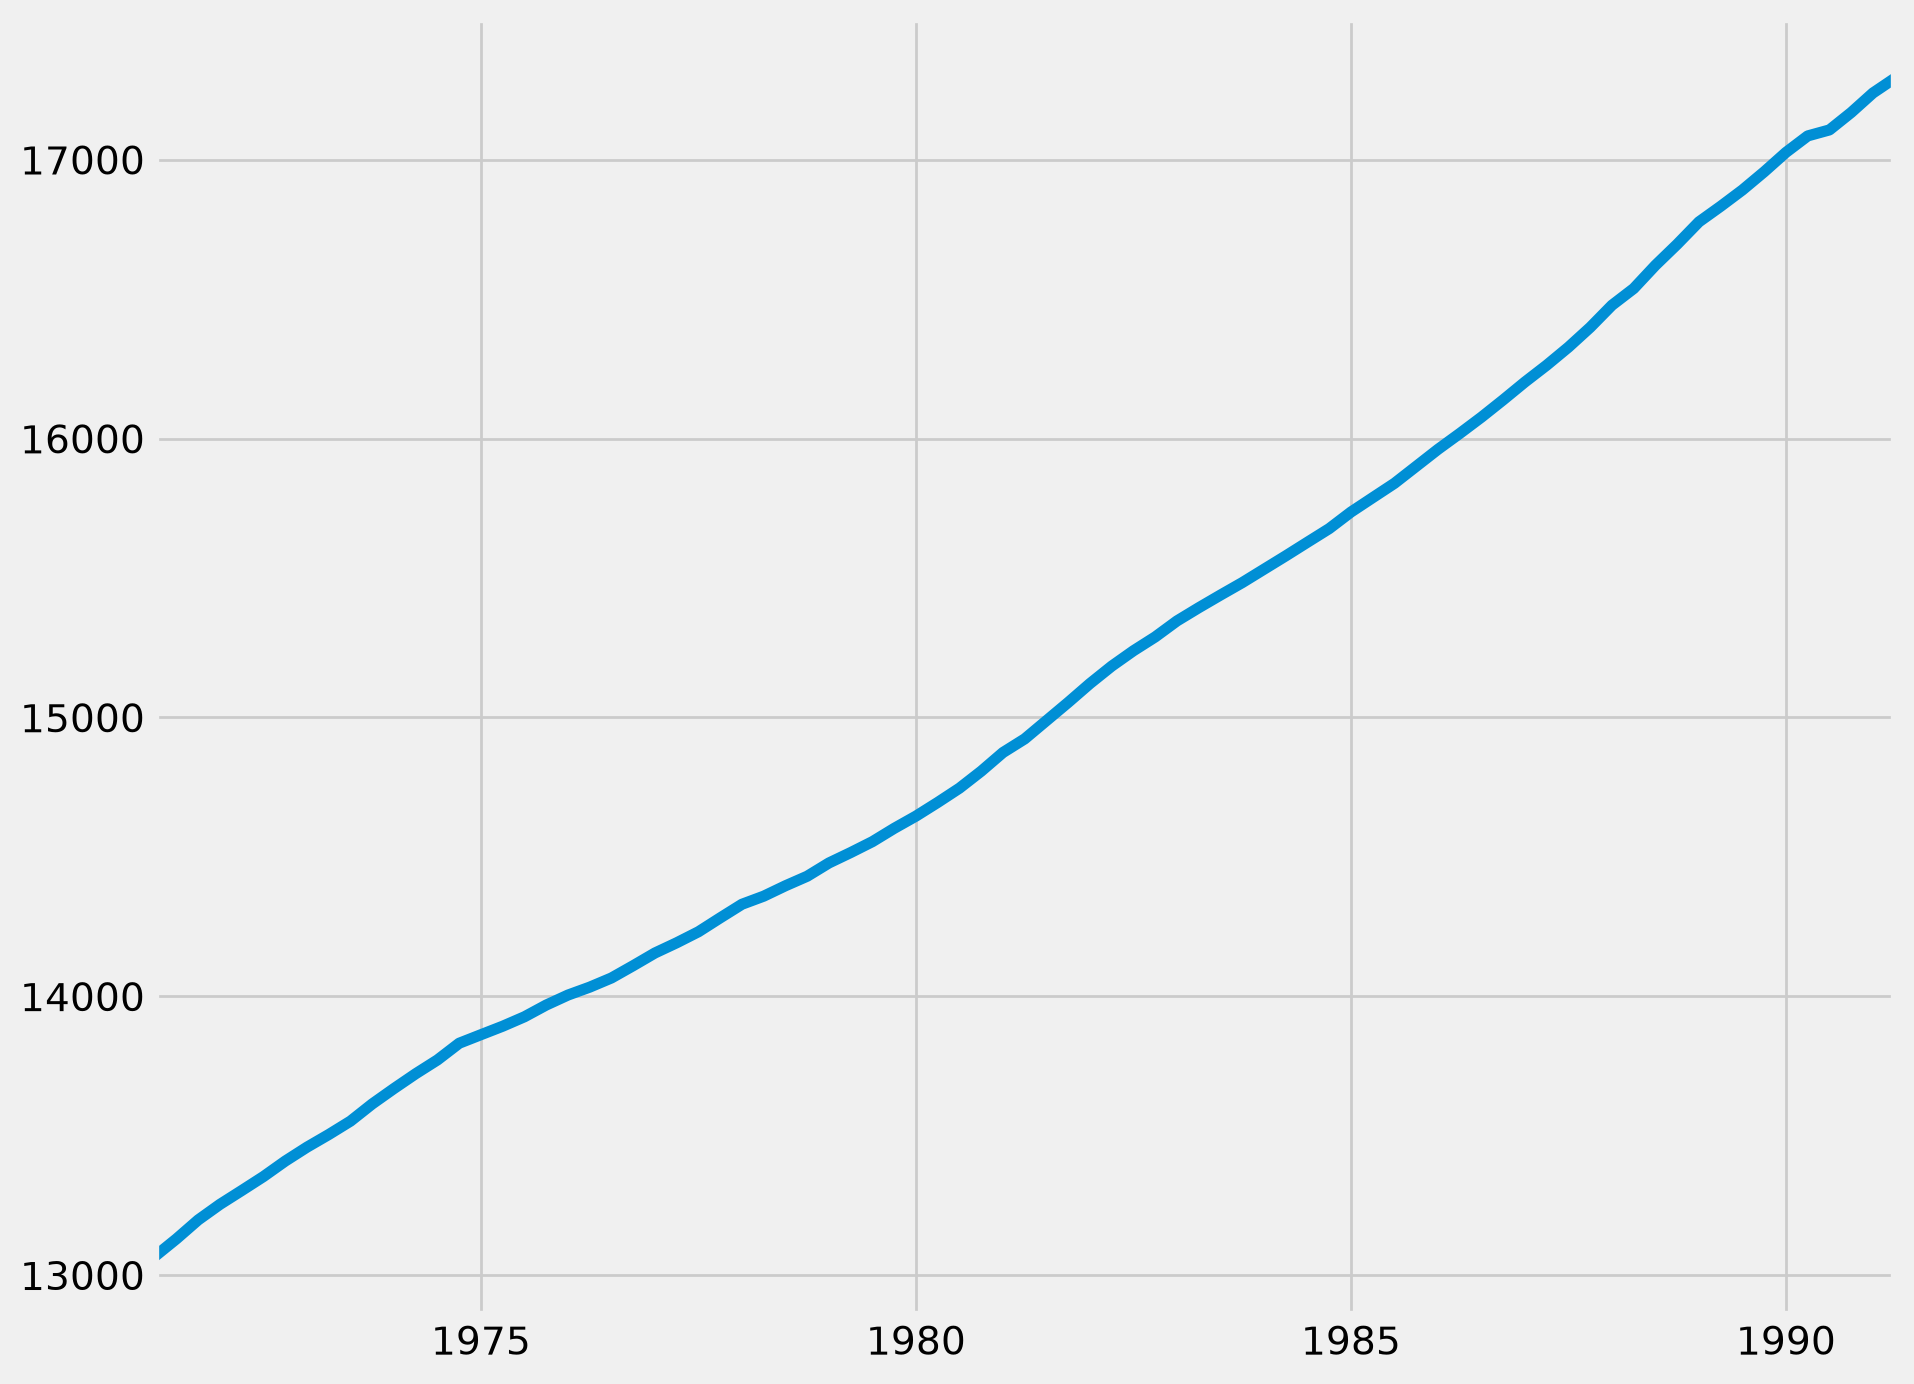

In [6]:
# YOUR CODE HERE
df_eda['residents'].plot(figsize=(10, 8))

## Part 2 - Seasonal Decomposition

A time series can be split into three components: **trend**, **seasonal**, and **residual**.

### 4. Decompose `residents` using `seasonal_decompose` (`period=4` since this is quarterly data). Plot the trend, seasonal, and residual components.

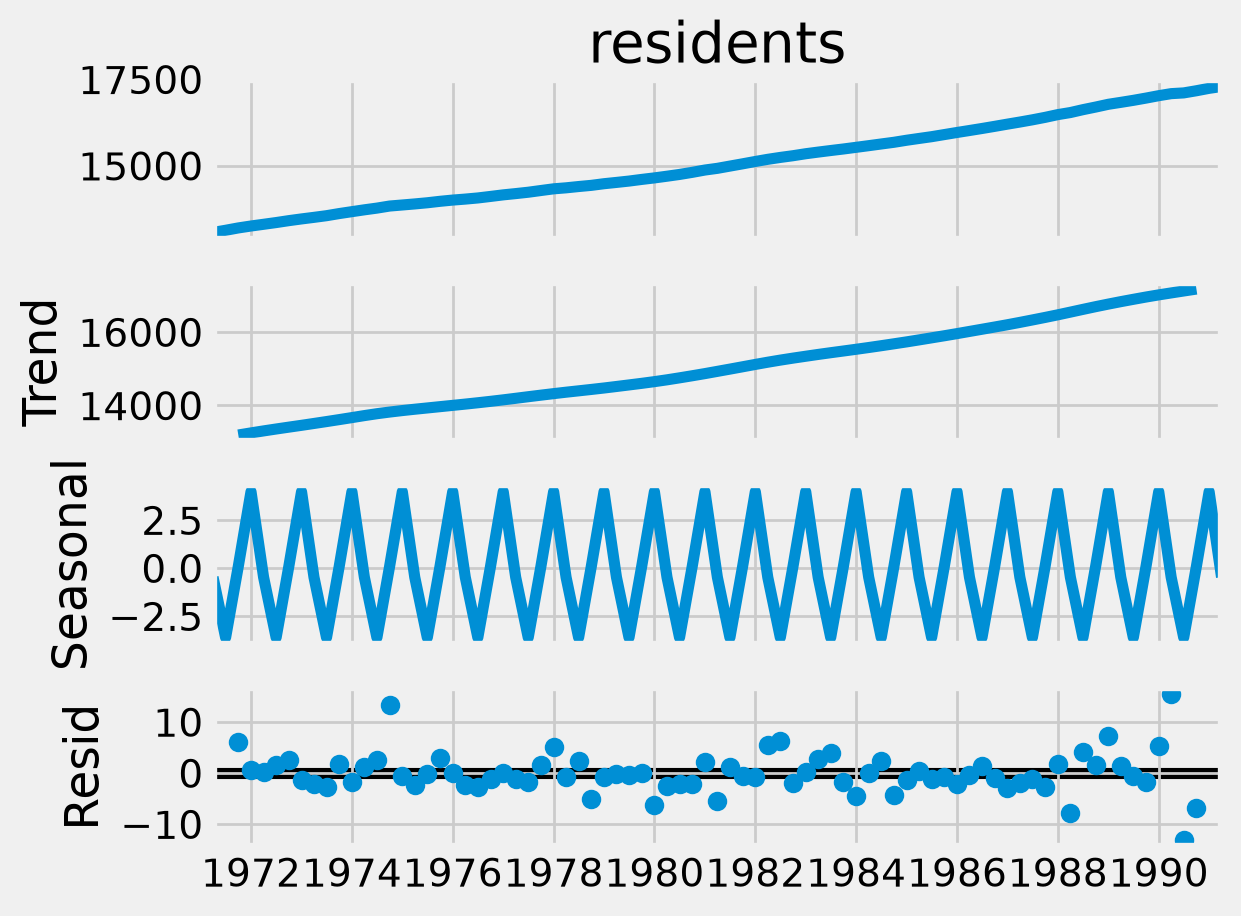

In [7]:
# YOUR CODE HERE
season = seasonal_decompose(df_eda['residents'], period=4)

season.plot()
plt.show()

## Part 3 - Visualizing Trend with Rolling Mean and Resampling.

With quarterly data, a 4-quarter (1-year) rolling window is the suitable choice, as it averages away any seasonal fluctuations and leaves just the trend.

### 5. Compute and plot a 4-quarter rolling mean of `residents`, overlaid on the raw series.

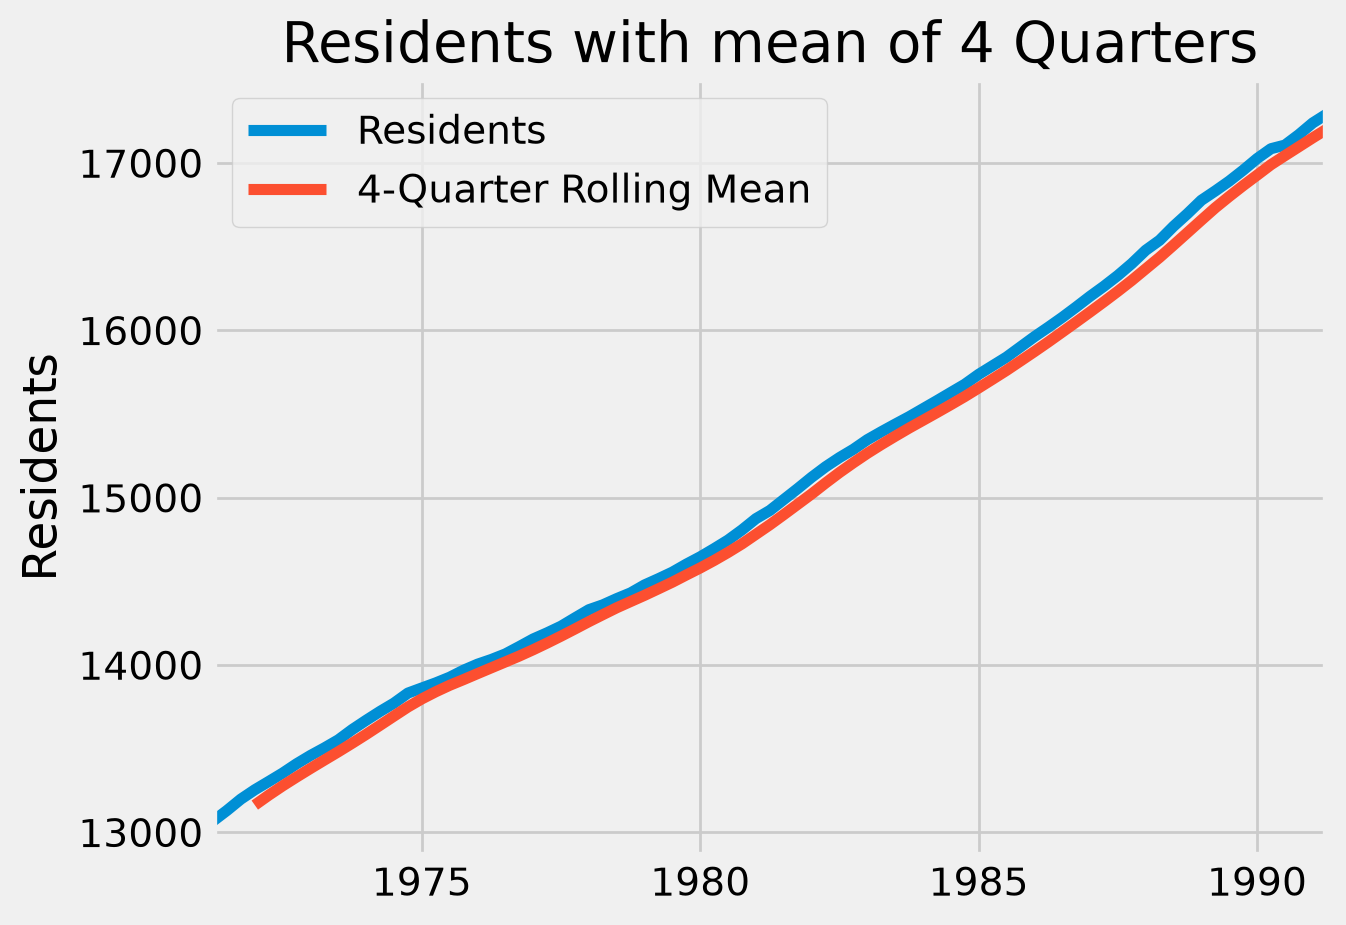

In [8]:
# YOUR CODE HERE
rolling_mean = df_eda['residents'].rolling(4).mean()

df_eda['residents'].plot(label='Residents')
rolling_mean.plot(label='4-Quarter Rolling Mean')
plt.title('Residents with mean of 4 Quarters')
plt.ylabel('Residents')
plt.legend()
plt.show()

### 6. Plot a 4-quarter rolling standard deviation. Is the spread of fluctuations roughly stable over time, or does it change?

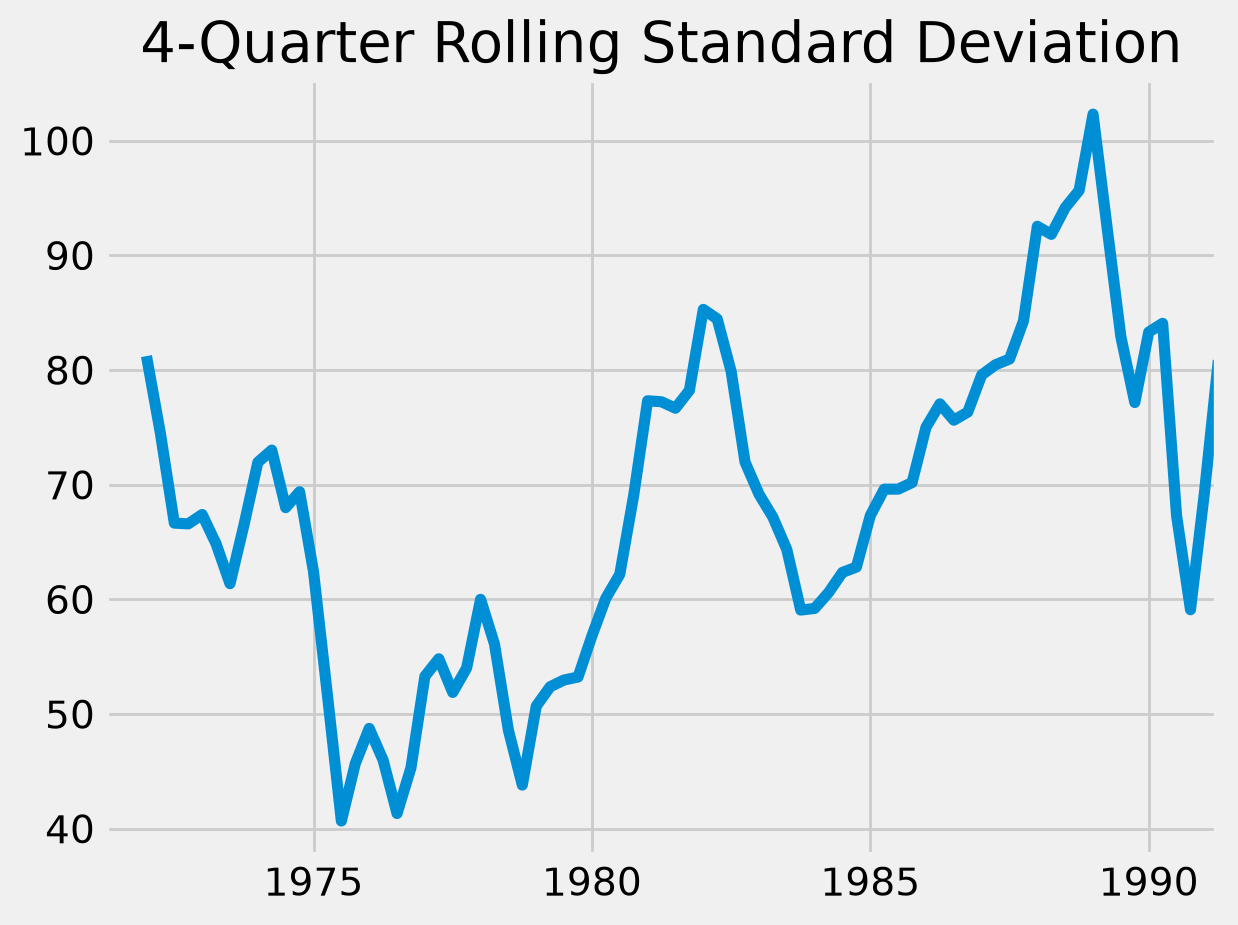

In [9]:
# YOUR CODE HERE
rolling_std = df_eda['residents'].rolling(4).std()
rolling_std.plot(title='4-Quarter Rolling Standard Deviation')
plt.show()

## Part 4 - Stationarity and the ADF Test

A stationary series has a constant mean, variance, and autocorrelation structure over time *(most classical forecasting models assume this)*. We test for it with the **Augmented Dickey-Fuller (ADF) test**:

- **Null hypothesis (H0):** the series has a unit root (i.e. it is *non-stationary*).
- If the p-value is small (typically ≤ 0.05), we reject H0 and conclude the series **is** *stationary*.

### 7. Write an `adf_test()` helper function that runs `adfuller()` and prints the test statistic, p-value, and a plain-English conclusion.

In [17]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series.dropna())

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    if result[1] < 0.05:
        print("The series is stationary.")
    else:
        print("The series is non-stationary.")   

### 8. Run `adf_test()` on the raw `residents` series. Then apply `.diff()` and run it again. Is one difference enough?

In [18]:
# YOUR CODE HERE
adf_test(df_eda['residents'])

ADF Statistic: 1.8104172434785872
p-value: 0.9983694557535389
The series is non-stationary.


In [20]:
adf_test(df_eda['residents'].diff())

ADF Statistic: -2.5056157803356958
p-value: 0.11411391714786173
The series is non-stationary.


### 9. If the first difference wasn't enough, try a second difference (`.diff().diff()`). Is it stationary now? 
*This will be your `d` term in the modeling stage*.

In [19]:
# YOUR CODE HERE
adf_test(df_eda['residents'].diff().diff())

ADF Statistic: -3.148284343513108
p-value: 0.023180220846990944
The series is stationary.


## Part 5 - Autocorrelation and Seasonality

ACF and PACF plots show how correlated a series is with its own past values at different lags. We look at these on the **differenced** series, with the trend removed, any repeating seasonal correlation stands out clearly instead of being buried under the trend's slow decay.

### 10. Plot the ACF and PACF of the series out to at least 20 lags.

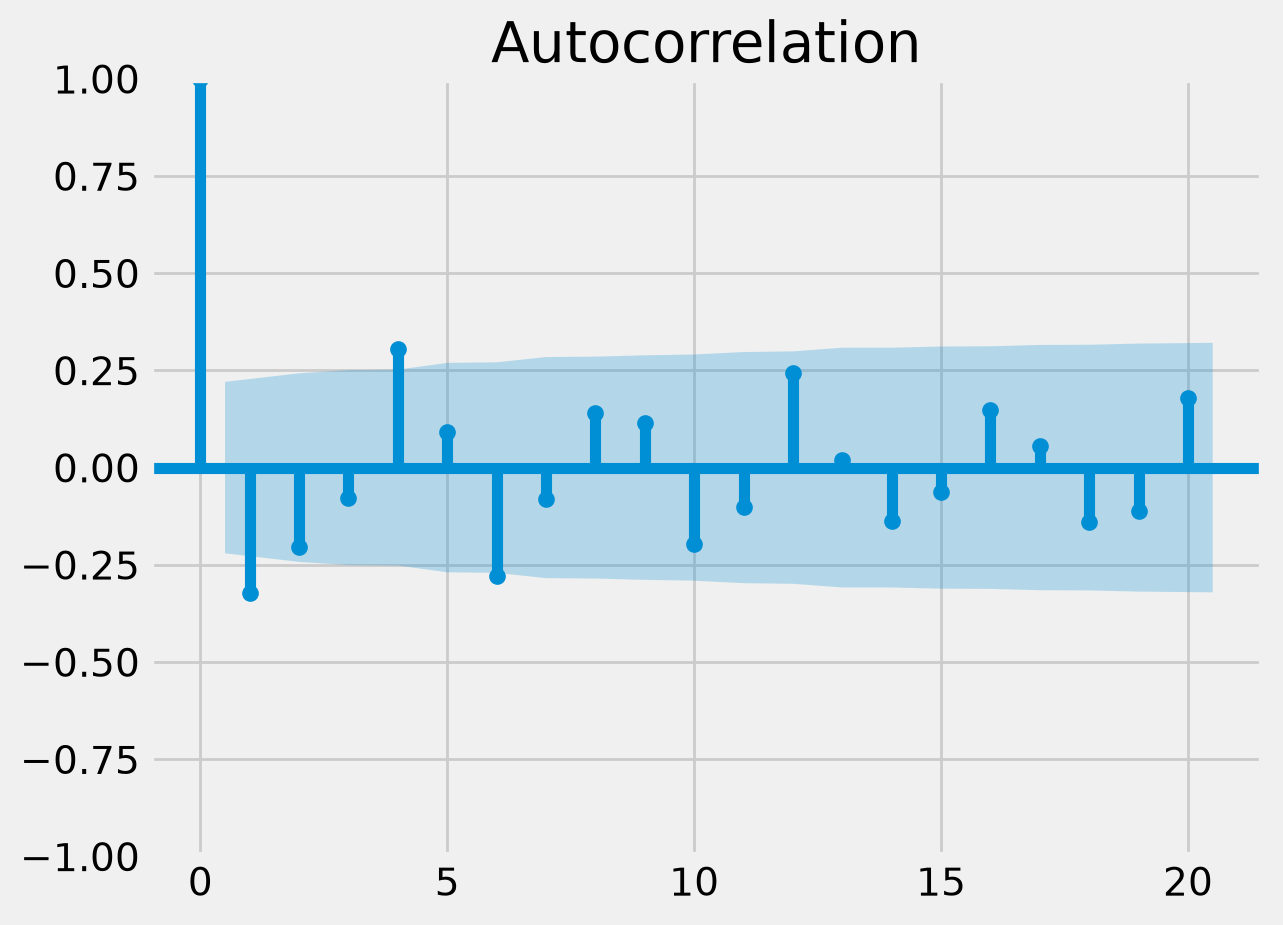

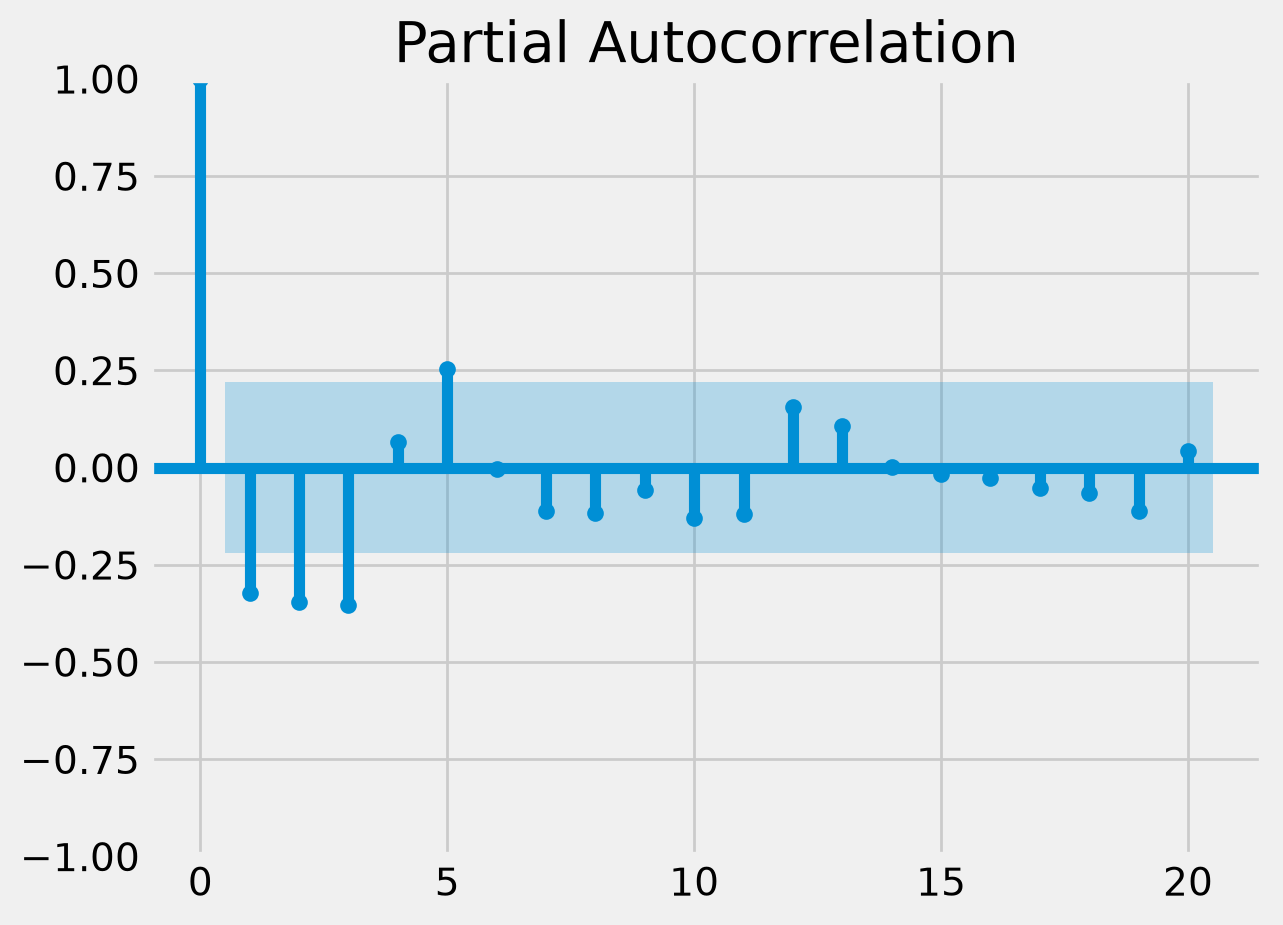

In [21]:
# YOUR CODE HERE
diff2 = df_eda['residents'].diff().diff().dropna()

plot_acf(diff2, lags=20)
plt.show()

plot_pacf(diff2, lags=20)
plt.show()

### 11. Look closely at the ACF plot. At which lag do you see the strongest spike? What does that tell you about the data?

_Your answer here_ : The strongest spike is at lag 1, showing a negative relationship between succesive quarters.